# Joint glitch + galactic binary inference — TDI 1 vs TDI 2

One-year LISA observation in the mHz band containing:
- A monochromatic **galactic binary** (GB) at f₀ = 2 mHz — narrow spectral line.
- A **shapelet glitch** at τ = 400 s — broadband 1/f² spectrum in the mHz band.

## Hybrid frequency-domain likelihood
The GB is spectrally well-resolved (power concentrated in N_GB = 256 fine bins).  
The glitch is broadband (smooth, slowly varying spectrum across the full band).

**Strategy**: split the likelihood into two complementary sums:
1. **Coarse grid** (every K-th fine bin, outside the GB window) — glitch model only.  
   Each coarse bin is weighted by K to represent K consecutive fine bins.
2. **Fine GB window** (N_WIN bins centred on f₀, fixed) — glitch + GB model.

The GB signal is placed inside the window with `jax.lax.dynamic_update_slice` so that  
f₀ can vary freely during sampling.

**TDI-1 / TDI-2 consistency** (same physics as `lisa.ipynb`):  
`h_TDI2 = −TFX1 · h_TDI1`, `n_TDI2 = −TFX1 · n_TDI1`, `S_TDI2 = |TFX1|² · S_TDI1`  
⟹ log L₂(θ) ≡ log L₁(θ). Both chains sample the same posterior.

**Inferred parameters** (7 total):  
`[log f₀, log ḟ, log A_GB, ψ_GB,   τ, log(Δv·β), log β]`  
Fixed: ra, dec, ι, φ₀.

> **Kernel**: use the `jaxgb` conda environment (`miniconda3/envs/jaxgb`).

In [1]:
import sys, os, time
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt

import lisaorbits
from jaxgb import jaxgb as jgb_mod

import jaxglitches as jg
from jaxglitches.waveform import tdi1_shap_f_glitch, tdi2_shap_f_glitch, AET
from jaxglitches.priors import _DELTAV_MIN, _DELTAV_MAX, _BETA_MIN, _BETA_MAX
import noise as ns

from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

from scipy.optimize import minimize as scipy_minimize

print('JAX devices:', jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX devices: [CpuDevice(id=0)]


## 1. Setup: observation, frequency grid, noise PSDs

In [2]:
YEAR_s         = 364 * 24 * 3600          # 1-year observation
SAMPLING_STEP_s = 1.0 / (2.0 * 3e-3)     # Nyquist for 3 mHz LISA band (~167 s)
T_ARM          = jg.T_ARM_s               # one-way light travel time ~8.336 s

n_samples = int(YEAR_s / SAMPLING_STEP_s)
YEAR_s    = n_samples * SAMPLING_STEP_s   # adjust to integer multiple

freq_fine  = jnp.fft.rfftfreq(n_samples, SAMPLING_STEP_s)   # (n_fine,)
n_fine     = len(freq_fine)
f_safe     = jnp.where(freq_fine > 0, freq_fine, 1.0)
df         = float(freq_fine[1])

psd1_fine  = ns.psd_tdi1_array(f_safe)   # (n_fine, 3)  TDI-1 [A, E, T]
psd2_fine  = ns.psd_tdi2_array(f_safe)   # (n_fine, 3)  TDI-2

# TDI-1 -> TDI-2 transfer function: h_TDI2 = -TFX1 * h_TDI1
TFX1 = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * f_safe)  # (n_fine,)

print(f'n_fine = {n_fine},  df = {df:.3e} Hz,  fmax = {float(freq_fine[-1]):.4f} Hz')

n_fine = 94349,  df = 3.180e-08 Hz,  fmax = 0.0030 Hz


## 2. True parameters, signal generation, SNR

In [3]:
# ── Galactic binary true parameters ──────────────────────────────────────────
F0_TRUE   = 2.0e-3    # Hz   (2 mHz)
FDOT_TRUE = 1.0e-19   # Hz/s
A_GB_TRUE = 1.0e-22   # dimensionless strain amplitude  (10× louder for better constraints)
PSI_TRUE  = jnp.pi / 4

# Fixed GB parameters (not inferred)
RA_TRUE, DEC_TRUE, IOTA_TRUE, PHI0_TRUE = 1.0, -0.5, 1.0, 0.0

gb_params_true = jnp.array([[F0_TRUE, FDOT_TRUE, A_GB_TRUE,
                               RA_TRUE, DEC_TRUE, PSI_TRUE, IOTA_TRUE, PHI0_TRUE]])

# ── Shapelet glitch true parameters (same as lisa.ipynb) ─────────────────────
TAU_TRUE    = 400.0         # s
DELTAV_TRUE = 1.2e-13       # m/s
BETA_TRUE   = 0.79          # s
A_G_TRUE    = DELTAV_TRUE * BETA_TRUE   # = 9.48e-14

glitch_params_true = jnp.array([TAU_TRUE, DELTAV_TRUE, BETA_TRUE])

# ── jaxgb model ───────────────────────────────────────────────────────────────
N_GB    = 256
orbit   = lisaorbits.EqualArmlengthOrbits()
jgb_model = jgb_mod.JaxGB(orbit, t_obs=float(YEAR_s), t0=0.0, n=N_GB)

k_min_true = int(jgb_model.get_kmin(gb_params_true[:, 0])[0])
print(f'k_min_true = {k_min_true},  freq[k_min] = {float(freq_fine[k_min_true]):.4e} Hz')

# ── GB signal (TDI-1.5 ≈ TDI-1) ──────────────────────────────────────────────
segs_true   = jgb_model.get_tdi(gb_params_true, tdi_generation=1.5, tdi_combination='AET')
segs_stacked = jnp.stack(segs_true, axis=0).astype(jnp.complex128)  # (3, 1, N_GB)
h_gb_win_true = segs_stacked[:, 0, :].T   # (N_GB, 3)

h_gb_tdi1 = jnp.zeros((n_fine, 3), dtype=jnp.complex128)
h_gb_tdi1 = h_gb_tdi1.at[k_min_true + jnp.arange(N_GB)].set(h_gb_win_true)

# ── Glitch signal (TDI-1) ─────────────────────────────────────────────────────
X, Y, Z = tdi1_shap_f_glitch(f_safe, TAU_TRUE, DELTAV_TRUE, BETA_TRUE, T_ARM)
A_ch, E_ch, T_ch = AET(X, Y, Z)
h_glitch_tdi1 = jnp.stack([A_ch, E_ch, T_ch], axis=-1).at[0].set(0+0j)  # (n_fine, 3)

# ── TDI-2 via -TFX1 transformation ───────────────────────────────────────────
h_gb_tdi2     = (-TFX1[:, None] * h_gb_tdi1    ).at[0].set(0+0j)
h_glitch_tdi2 = (-TFX1[:, None] * h_glitch_tdi1).at[0].set(0+0j)

# ── SNR check ────────────────────────────────────────────────────────────────
snr_gb1 = float(jg.snr(h_gb_tdi1, psd1_fine))
snr_gb2 = float(jg.snr(h_gb_tdi2, psd2_fine))
snr_g1  = float(jg.snr(h_glitch_tdi1, psd1_fine))
snr_g2  = float(jg.snr(h_glitch_tdi2, psd2_fine))
print(f'GB     SNR  TDI-1: {snr_gb1:.1f}   TDI-2: {snr_gb2:.1f}   ratio: {snr_gb2/snr_gb1:.6f}')
print(f'Glitch SNR  TDI-1: {snr_g1:.1f}   TDI-2: {snr_g2:.1f}   ratio: {snr_g2/snr_g1:.6f}')

k_min_true = 62771,  freq[k_min] = 1.9959e-03 Hz
GB     SNR  TDI-1: 4955.3   TDI-2: 4955.3   ratio: 1.000000
Glitch SNR  TDI-1: 552.0   TDI-2: 552.0   ratio: 1.000000


In [4]:
# ── Noise + data ─────────────────────────────────────────────────────────────
key = jr.PRNGKey(0)
kn, _ = jr.split(key)
n_fd_tdi1 = ns.sample_noise_fd(kn, psd1_fine)
# TDI-2 noise derived from TDI-1 (same physical realisation, per lisa.ipynb)
n_fd_tdi2 = (-TFX1[:, None] * n_fd_tdi1).at[0].set(0+0j)

data_tdi1 = h_gb_tdi1 + h_glitch_tdi1 + n_fd_tdi1
data_tdi2 = h_gb_tdi2 + h_glitch_tdi2 + n_fd_tdi2

ip1 = float(jg.inner_product(data_tdi1, h_gb_tdi1+h_glitch_tdi1, psd1_fine))
ip2 = float(jg.inner_product(data_tdi2, h_gb_tdi2+h_glitch_tdi2, psd2_fine))
snr_tot = float(jg.snr(h_gb_tdi1+h_glitch_tdi1, psd1_fine))
print(f'(d|h)/SNR²  TDI-1: {ip1/snr_tot**2:.4f}  TDI-2: {ip2/snr_tot**2:.4f}  (exp ≈ 1)')

(d|h)/SNR²  TDI-1: 0.9997  TDI-2: 0.9997  (exp ≈ 1)


## 3. Hybrid frequency grid

- **Coarse grid**: every `K`-th fine bin, excluding the GB window.
- **Fine GB window**: `N_WIN = N_GB + 2·BUF` bins centred on `k_min_true` (fixed).

The glitch contribution in the window is computed at the fixed window frequencies.  
The GB signal is placed dynamically (varies with sampled f₀) via `jax.lax.dynamic_update_slice`.

In [5]:
K   = 50     # decimation factor for coarse grid
              # K=50 keeps effective Fisher SNR for glitch params ≥ SNR/√50 ≈ 78
              # K=1000 amplified per-bin noise by √1000≈32, making β noise-dominated
BUF = 64     # extra bins on each side of the GB window

K_WIN_LO = max(1, k_min_true - BUF)
N_WIN    = N_GB + 2 * BUF          # = 384
K_WIN_HI = K_WIN_LO + N_WIN

# Fixed window arrays (precomputed, not recomputed per likelihood call)
freq_win_np   = np.array(freq_fine[K_WIN_LO:K_WIN_HI])           # (N_WIN,)
data_win1_np  = np.array(data_tdi1[K_WIN_LO:K_WIN_HI])           # (N_WIN, 3)
data_win2_np  = np.array(data_tdi2[K_WIN_LO:K_WIN_HI])
psd_win1_np   = np.array(psd1_fine[K_WIN_LO:K_WIN_HI])
psd_win2_np   = np.array(psd2_fine[K_WIN_LO:K_WIN_HI])

freq_win_jnp  = jnp.array(freq_win_np)
data_win1     = jnp.array(data_win1_np)
data_win2     = jnp.array(data_win2_np)
psd_win1      = jnp.array(psd_win1_np)
psd_win2      = jnp.array(psd_win2_np)

# Coarse grid: every K-th bin, skipping the GB window and DC
coarse_all = np.arange(1, n_fine, K)
mask_out   = (coarse_all < K_WIN_LO) | (coarse_all >= K_WIN_HI)
coarse_idx = coarse_all[mask_out]
N_COARSE   = len(coarse_idx)

freq_c1    = jnp.array(freq_fine[coarse_idx])
data_c1    = jnp.array(data_tdi1[coarse_idx])
data_c2    = jnp.array(data_tdi2[coarse_idx])
psd_c1     = jnp.array(psd1_fine[coarse_idx])
psd_c2     = jnp.array(psd2_fine[coarse_idx])

print(f'N_COARSE = {N_COARSE}  (K={K})')
print(f'N_WIN    = {N_WIN}  [k={K_WIN_LO} .. {K_WIN_HI-1}]')
print(f'Total hybrid bins = {N_COARSE + N_WIN}  vs  {n_fine} full  '
      f'(~{(N_COARSE+N_WIN)/n_fine*100:.2f}% of data,  ~{n_fine/(N_COARSE+N_WIN):.0f}× speedup)')

N_COARSE = 1880  (K=50)
N_WIN    = 384  [k=62707 .. 63090]
Total hybrid bins = 2264  vs  94349 full  (~2.40% of data,  ~42× speedup)


## 4. Template functions

In [6]:
@jax.jit
def glitch_h_tdi1(g3, freqs):
    """Glitch TDI-1 signal at arbitrary frequencies. g3 = [tau, Deltav, beta]."""
    tau, Deltav, beta = g3[0], g3[1], g3[2]
    f_s = jnp.where(freqs > 0, freqs, 1.0)
    X, Y, Z = tdi1_shap_f_glitch(f_s, tau, Deltav, beta, T_ARM)
    Ac, Ec, Tc = AET(X, Y, Z)
    return jnp.stack([Ac, Ec, Tc], axis=-1)   # (F, 3)


@jax.jit
def glitch_h_tdi2(g3, freqs):
    """Glitch TDI-2 = -TFX1 * TDI-1."""
    h1 = glitch_h_tdi1(g3, freqs)
    f_s = jnp.where(freqs > 0, freqs, 1.0)
    tfx = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * f_s)
    return (-tfx[:, None] * h1)


@jax.jit
def gb_tdi1_segment(gb8):
    """
    GB signal at its N_GB frequency bins (TDI-1.5 ≈ TDI-1 for the glitch analysis).
    Returns (h_seg, k_offset) where h_seg has shape (N_GB, 3) and k_offset is the
    offset of those bins relative to K_WIN_LO (the fixed window start).
    """
    p   = gb8[None, :]   # (1, 8)
    segs = jgb_model.get_tdi(p, tdi_generation=1.5, tdi_combination='AET')
    h_seg = jnp.stack(segs, axis=0).astype(jnp.complex128)[:, 0, :].T  # (N_GB, 3)
    k_min = jgb_model.get_kmin(p[:, 0])[0]                              # int32 scalar
    k_offset = (k_min - K_WIN_LO).astype(jnp.int32)
    return h_seg, k_offset


# Quick smoke test
h_seg_test, k_off_test = gb_tdi1_segment(gb_params_true[0])
print(f'gb_tdi1_segment: h_seg shape={h_seg_test.shape}, k_offset={int(k_off_test)}')

gb_tdi1_segment: h_seg shape=(256, 3), k_offset=64


## 5. Parameterisation and priors

Sampling vector `θ = [log f₀, log ḟ, log A_GB, ψ,   τ, log A_g, log β]`  
where `A_g = Δv · β` (glitch amplitude) and `β` (shapelet timescale).

In [7]:
# GB prior bounds (from lisa_GB.py, extended amplitude range for louder GB)
F0_MIN,   F0_MAX   = 1e-4,   3e-3
FDOT_MIN, FDOT_MAX = 1e-22,  4e-18
AGB_MIN,  AGB_MAX  = 1e-25,  1.7e-22   # upper bound raised to accommodate 1e-22 amplitude
PSI_MIN,  PSI_MAX  = 0.0,    float(jnp.pi)

# Glitch prior bounds (from jaxglitches.priors)
AG_MIN  = _DELTAV_MIN * _BETA_MIN
AG_MAX  = _DELTAV_MAX * _BETA_MAX
LAG_MIN, LAG_MAX   = float(jnp.log(AG_MIN)),    float(jnp.log(AG_MAX))
LBET_MIN, LBET_MAX = float(jnp.log(_BETA_MIN)), float(jnp.log(_BETA_MAX))
LDV_MIN,  LDV_MAX  = float(jnp.log(_DELTAV_MIN)), float(jnp.log(_DELTAV_MAX))
TAU_MIN,  TAU_MAX  = 0.0, float(YEAR_s)

# True sampling-space values
theta_true = jnp.array([
    float(jnp.log(F0_TRUE)),   float(jnp.log(FDOT_TRUE)), float(jnp.log(A_GB_TRUE)),
    float(PSI_TRUE),
    TAU_TRUE, float(jnp.log(A_G_TRUE)), float(jnp.log(BETA_TRUE))
])
print('theta_true =', np.array(theta_true))


def to_physical(theta):
    """θ -> (gb8_params, glitch3_params)."""
    f0   = jnp.exp(theta[0])
    fdot = jnp.exp(theta[1])
    A_gb = jnp.exp(theta[2])
    psi  = theta[3]
    # Build 8-component GB vector with fixed sky / orientation
    gb8_base = jnp.array([0., 0., 0., RA_TRUE, DEC_TRUE, 0., IOTA_TRUE, PHI0_TRUE])
    gb8 = gb8_base.at[0].set(f0).at[1].set(fdot).at[2].set(A_gb).at[5].set(psi)

    beta   = jnp.exp(theta[6])
    Deltav = jnp.exp(theta[5]) / beta   # A_g = Deltav * beta
    g3 = jnp.stack([theta[4], Deltav, beta])
    return gb8, g3


@jax.jit
def log_prior(theta):
    ok = (
        (theta[0] >= jnp.log(F0_MIN))   & (theta[0] <= jnp.log(F0_MAX))
      & (theta[1] >= jnp.log(FDOT_MIN)) & (theta[1] <= jnp.log(FDOT_MAX))
      & (theta[2] >= jnp.log(AGB_MIN))  & (theta[2] <= jnp.log(AGB_MAX))
      & (theta[3] >= PSI_MIN)           & (theta[3] <= PSI_MAX)
      & (theta[4] >= TAU_MIN)           & (theta[4] <= TAU_MAX)
      & (theta[5] >= LAG_MIN)           & (theta[5] <= LAG_MAX)
      & (theta[5] - theta[6] >= LDV_MIN) & (theta[5] - theta[6] <= LDV_MAX)
      & (theta[6] >= LBET_MIN)          & (theta[6] <= LBET_MAX)
    )
    return jnp.where(ok, 0.0, -jnp.inf)

theta_true = [-6.21460810e+00 -4.37491168e+01 -5.06568720e+01  7.85398163e-01
  4.00000000e+02 -2.99870070e+01 -2.35722334e-01]


## 6. Hybrid log-likelihoods

In [8]:
def _build_log_lik(data_c, psd_c, data_w, psd_w, tdi):
    """
    Factory for the hybrid log-likelihood.

    L(θ) =  −K · Σ_{coarse} |d_c − h_glitch_c|² / S_c
           − Σ_{window}  |d_w − h_GB_in_window − h_glitch_w|² / S_w

    Parameters
    ----------
    data_c, psd_c : coarse data / PSD  (N_COARSE, 3)
    data_w, psd_w : window data / PSD  (N_WIN, 3)
    tdi            : 1 or 2
    """
    dc, pc = data_c, psd_c
    dw, pw = data_w, psd_w
    _zero32 = jnp.zeros((), dtype=jnp.int32)   # type-stable zero for dynamic_update_slice

    @jax.jit
    def log_L(theta):
        gb8, g3 = to_physical(theta)

        # ── Coarse grid: glitch only ──────────────────────────────────────
        h_g_c = glitch_h_tdi1(g3, freq_c1) if tdi == 1 else glitch_h_tdi2(g3, freq_c1)
        L_coarse = -K * jnp.sum(jnp.abs(dc - h_g_c)**2 / pc)

        # ── GB window: GB + glitch ────────────────────────────────────────
        h_gb_seg, k_offset = gb_tdi1_segment(gb8)   # (N_GB, 3), int32
        if tdi == 2:
            # Convert GB to TDI-2 at the (dynamic) N_GB fine frequencies
            freq_gb = jax.lax.dynamic_slice(freq_win_jnp, (k_offset,), (N_GB,))
            tfx = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * freq_gb)
            h_gb_seg = (-tfx[:, None] * h_gb_seg)

        # Place GB signal into the fixed-size window array at dynamic offset
        # Both start-index components must share the same integer type (int32).
        h_gb_w = jnp.zeros((N_WIN, 3), dtype=jnp.complex128)
        h_gb_w = jax.lax.dynamic_update_slice(h_gb_w, h_gb_seg, (k_offset, _zero32))

        h_g_w = glitch_h_tdi1(g3, freq_win_jnp) if tdi == 1 else glitch_h_tdi2(g3, freq_win_jnp)
        L_win = -jnp.sum(jnp.abs(dw - h_gb_w - h_g_w)**2 / pw)

        return L_coarse + L_win

    return log_L


log_lik_tdi1 = _build_log_lik(data_c1, psd_c1, data_win1, psd_win1, tdi=1)
log_lik_tdi2 = _build_log_lik(data_c2, psd_c2, data_win2, psd_win2, tdi=2)

# Sanity: both should be equal at truth (by TDI symmetry)
ll1 = float(log_lik_tdi1(theta_true))
ll2 = float(log_lik_tdi2(theta_true))
print(f'log L at truth:  TDI-1 = {ll1:.3f}')
print(f'                 TDI-2 = {ll2:.3f}')
print(f'Difference (must be ≈ 0): {ll2 - ll1:.4f}')

log L at truth:  TDI-1 = -283384.858
                 TDI-2 = -283384.858
Difference (must be ≈ 0): 0.0000


In [9]:
# ── SNR from hybrid grid vs full grid ────────────────────────────────────────
# Glitch SNR from coarse part only (K-weighted)
h_g_c_true = glitch_h_tdi1(glitch_params_true, freq_c1)
snr_g_coarse = float(jnp.sqrt(K * 2.0 * jnp.sum(jnp.abs(h_g_c_true)**2 / psd_c1)))

h_g_w_true = glitch_h_tdi1(glitch_params_true, freq_win_jnp)
snr_g_win   = float(jnp.sqrt(2.0 * jnp.sum(jnp.abs(h_g_w_true)**2 / psd_win1)))

snr_g_hybrid = float(jnp.sqrt(K * 2.0 * jnp.sum(jnp.abs(h_g_c_true)**2 / psd_c1)
                              + 2.0 * jnp.sum(jnp.abs(h_g_w_true)**2 / psd_win1)))

print(f'Glitch SNR — full fine grid: {snr_g1:.1f}')
print(f'           — hybrid coarse:  {snr_g_coarse:.1f}')
print(f'           — hybrid window:  {snr_g_win:.1f}')
print(f'           — hybrid total:   {snr_g_hybrid:.1f}  (should be close to full)')

# GB SNR from window
snr_gb_win = float(jg.snr(
    jnp.zeros((N_WIN,3),dtype=jnp.complex128).at[BUF:BUF+N_GB].set(h_gb_win_true),
    psd_win1))
print(f'\nGB SNR — full fine grid: {snr_gb1:.1f}')
print(f'       — window only:    {snr_gb_win:.1f}  (should match since GB is fully in window)')

Glitch SNR — full fine grid: 552.0
           — hybrid coarse:  550.6
           — hybrid window:  38.2
           — hybrid total:   551.9  (should be close to full)

GB SNR — full fine grid: 4955.3
       — window only:    4955.3  (should match since GB is fully in window)


## 7. jexplore ensemble sampling

### 7.1 TDI-1

In [10]:
N_WALKERS = 16
N_BURN    = 2_000
N_SAMP    = 20_000
DIM       = 7

@jax.jit
def lp1(theta): return log_lik_tdi1(theta) + log_prior(theta)

@jax.jit
def lp2(theta): return log_lik_tdi2(theta) + log_prior(theta)

# ── MAP via L-BFGS-B ─────────────────────────────────────────────────────────
def find_map(lp_fn, xi_init):
    grad_lp = jax.jit(jax.grad(lp_fn))
    res = scipy_minimize(
        lambda x: -float(lp_fn(jnp.array(x))),
        np.array(xi_init),
        jac=lambda x: -np.array(grad_lp(jnp.array(x))),
        method='L-BFGS-B',
        options={'maxiter': 3000, 'ftol': 1e-15, 'gtol': 1e-8}
    )
    return jnp.array(res.x)

print('Finding MAP (TDI-1)...')
t0 = time.time()
theta_map1 = find_map(lp1, theta_true)
print(f'  done in {time.time()-t0:.1f} s')
print(f'  MAP vs truth:')
labels = ['log_f0','log_fdot','log_A_gb','psi','tau','log_Ag','log_beta']
for l, v_map, v_true in zip(labels, np.array(theta_map1), np.array(theta_true)):
    print(f'    {l:12s}: MAP={v_map:.6f}  truth={v_true:.6f}')

Finding MAP (TDI-1)...
  done in 1.1 s
  MAP vs truth:
    log_f0      : MAP=-6.214608  truth=-6.214608
    log_fdot    : MAP=-43.749117  truth=-43.749117
    log_A_gb    : MAP=-50.657182  truth=-50.656872
    psi         : MAP=0.785427  truth=0.785398
    tau         : MAP=400.000000  truth=400.000000
    log_Ag      : MAP=-29.987160  truth=-29.987007
    log_beta    : MAP=-0.235719  truth=-0.235722


In [11]:
# Laplace covariance at MAP (for walker initialisation)
print('Computing Hessian at MAP (TDI-1)...')
t0 = time.time()
H1 = jax.hessian(lp1)(theta_map1)
C1 = -jnp.linalg.inv(H1)
print(f'  done in {time.time()-t0:.1f} s')

# Robust σ: log_f0 has near-zero σ (very tight line), log_fdot is flat (unresolvable chirp).
# Replace NaN / zero / inf on the diagonal with per-parameter fallback step sizes
# so that walker initialisation is well-conditioned.
_FALLBACK_SIGMA = np.array([
    1e-7,   # log_f0:   frequency bin is ~exact
    2.0,    # log_fdot: unconstrained — spread walkers over prior
    0.02,   # log_A_gb
    0.05,   # psi
    0.5,    # tau (s)
    0.02,   # log_Ag
    0.3,    # log_beta
])
sigma1_raw = np.sqrt(np.abs(np.diag(np.array(C1))))
sigma1 = np.where(
    np.isfinite(sigma1_raw) & (sigma1_raw > 1e-8) & (sigma1_raw < 10.0),
    sigma1_raw, _FALLBACK_SIGMA
)
C1_init = np.diag(sigma1**2)   # diagonal covariance for initialisation
print('Laplace 1σ:', dict(zip(labels, sigma1.round(4))))

Computing Hessian at MAP (TDI-1)...
  done in 2.5 s
Laplace 1σ: {'log_f0': np.float64(0.0), 'log_fdot': np.float64(3.1205), 'log_A_gb': np.float64(0.0002), 'psi': np.float64(0.0001), 'tau': np.float64(0.1553), 'log_Ag': np.float64(0.0018), 'log_beta': np.float64(0.123)}


In [12]:
def run_chain(loglik_fn, theta_map, C_init, seed):
    sampling = SamplingMH(
        nwalker=N_WALKERS, temps=jnp.array([1.0]),
        loglik=loglik_fn, logprior=log_prior, dim=DIM,
    )
    _steps = Steps([{Stretch(permute=True).builder: 1.0}])

    rng  = np.random.default_rng(seed)
    # Initialise walkers tightly around MAP using the robust diagonal covariance
    p0   = np.array(theta_map) + rng.multivariate_normal(np.zeros(DIM), np.array(C_init)*0.01, N_WALKERS)

    iepoch  = EpochMH({'p': p0})
    backend = DefaultBackend(burn=N_BURN, inmem_epochs=1)
    JaxSampler(sampling, _steps, backend).run(
        iepoch, niters=N_BURN + N_SAMP, nepoch=1, seed=seed
    )
    # (N_WALKERS, DIM, N_SAMP) -> (N_WALKERS*N_SAMP, DIM)
    s = backend.get_samples()['p']
    return jnp.array(s.transpose(0, 2, 1).reshape(-1, DIM))

print(f'Running TDI-1 chain  ({N_WALKERS} walkers × {N_BURN+N_SAMP} iters)...')
t0 = time.time()
chain1 = run_chain(log_lik_tdi1, theta_map1, C1_init, seed=1)
print(f'  done in {time.time()-t0:.1f} s,  {chain1.shape[0]:,} samples')

Running TDI-1 chain  (16 walkers × 22000 iters)...
  done in 50.1 s,  320,000 samples


### 7.2 TDI-2

In [13]:
print('Finding MAP (TDI-2)...')
t0 = time.time()
theta_map2 = find_map(lp2, theta_true)
print(f'  done in {time.time()-t0:.1f} s')

print('Computing Hessian at MAP (TDI-2)...')
t0 = time.time()
H2 = jax.hessian(lp2)(theta_map2)
C2 = -jnp.linalg.inv(H2)
print(f'  done in {time.time()-t0:.1f} s')

sigma2_raw = np.sqrt(np.abs(np.diag(np.array(C2))))
sigma2 = np.where(
    np.isfinite(sigma2_raw) & (sigma2_raw > 1e-8) & (sigma2_raw < 10.0),
    sigma2_raw, _FALLBACK_SIGMA
)
C2_init = np.diag(sigma2**2)

print(f'Running TDI-2 chain  ({N_WALKERS} walkers × {N_BURN+N_SAMP} iters)...')
t0 = time.time()
chain2 = run_chain(log_lik_tdi2, theta_map2, C2_init, seed=2)
print(f'  done in {time.time()-t0:.1f} s,  {chain2.shape[0]:,} samples')

Finding MAP (TDI-2)...
  done in 1.0 s
Computing Hessian at MAP (TDI-2)...
  done in 1.8 s
Running TDI-2 chain  (16 walkers × 22000 iters)...
  done in 51.7 s,  320,000 samples


## 8. Posterior summary

In [14]:
# Convert to physical parameters for display
def chain_to_physical(chain):
    """Returns array of shape (N, 7) in physical units:
    [f0 (Hz), fdot (Hz/s), A_GB, psi (rad), tau (s), A_g = Dv*beta (m), beta (s)]
    """
    f0   = np.exp(np.array(chain[:, 0]))
    fdot = np.exp(np.array(chain[:, 1]))
    A_gb = np.exp(np.array(chain[:, 2]))
    psi  = np.array(chain[:, 3])
    tau  = np.array(chain[:, 4])
    Ag   = np.exp(np.array(chain[:, 5]))
    beta = np.exp(np.array(chain[:, 6]))
    return np.column_stack([f0, fdot, A_gb, psi, tau, Ag, beta])

phys1 = chain_to_physical(chain1)
phys2 = chain_to_physical(chain2)

truth_phys = [F0_TRUE, FDOT_TRUE, A_GB_TRUE, float(PSI_TRUE), TAU_TRUE, A_G_TRUE, BETA_TRUE]
param_names = ['f₀ (Hz)', 'ḟ (Hz/s)', 'A_GB', 'ψ (rad)', 'τ (s)', 'A_g=Δv·β (m)', 'β (s)']

print(f'{"Parameter":20s}  {"TDI-1 median":>16s}  {"TDI-2 median":>16s}  {"Truth":>16s}')
print('-' * 74)
for name, v1, v2, tv in zip(param_names, np.median(phys1,0), np.median(phys2,0), truth_phys):
    print(f'{name:20s}  {v1:16.4e}  {v2:16.4e}  {tv:16.4e}')

Parameter                 TDI-1 median      TDI-2 median             Truth
--------------------------------------------------------------------------
f₀ (Hz)                     2.0000e-03        2.0000e-03        2.0000e-03
ḟ (Hz/s)                    4.0634e-20        4.2067e-20        1.0000e-19
A_GB                        9.9972e-23        9.9970e-23        1.0000e-22
ψ (rad)                     7.8545e-01        7.8545e-01        7.8540e-01
τ (s)                       3.7790e+02        3.7645e+02        4.0000e+02
A_g=Δv·β (m)                9.7556e-14        9.8005e-14        9.4800e-14
β (s)                       1.2279e+01        1.3033e+01        7.9000e-01


## 9. Corner plots — TDI-1 vs TDI-2

All 7 parameters.  GB parameters in log scale (log₁₀), glitch τ in seconds, A_g and β in log scale.  
Black dashed lines = true values.  Blue = TDI-1, red = TDI-2.

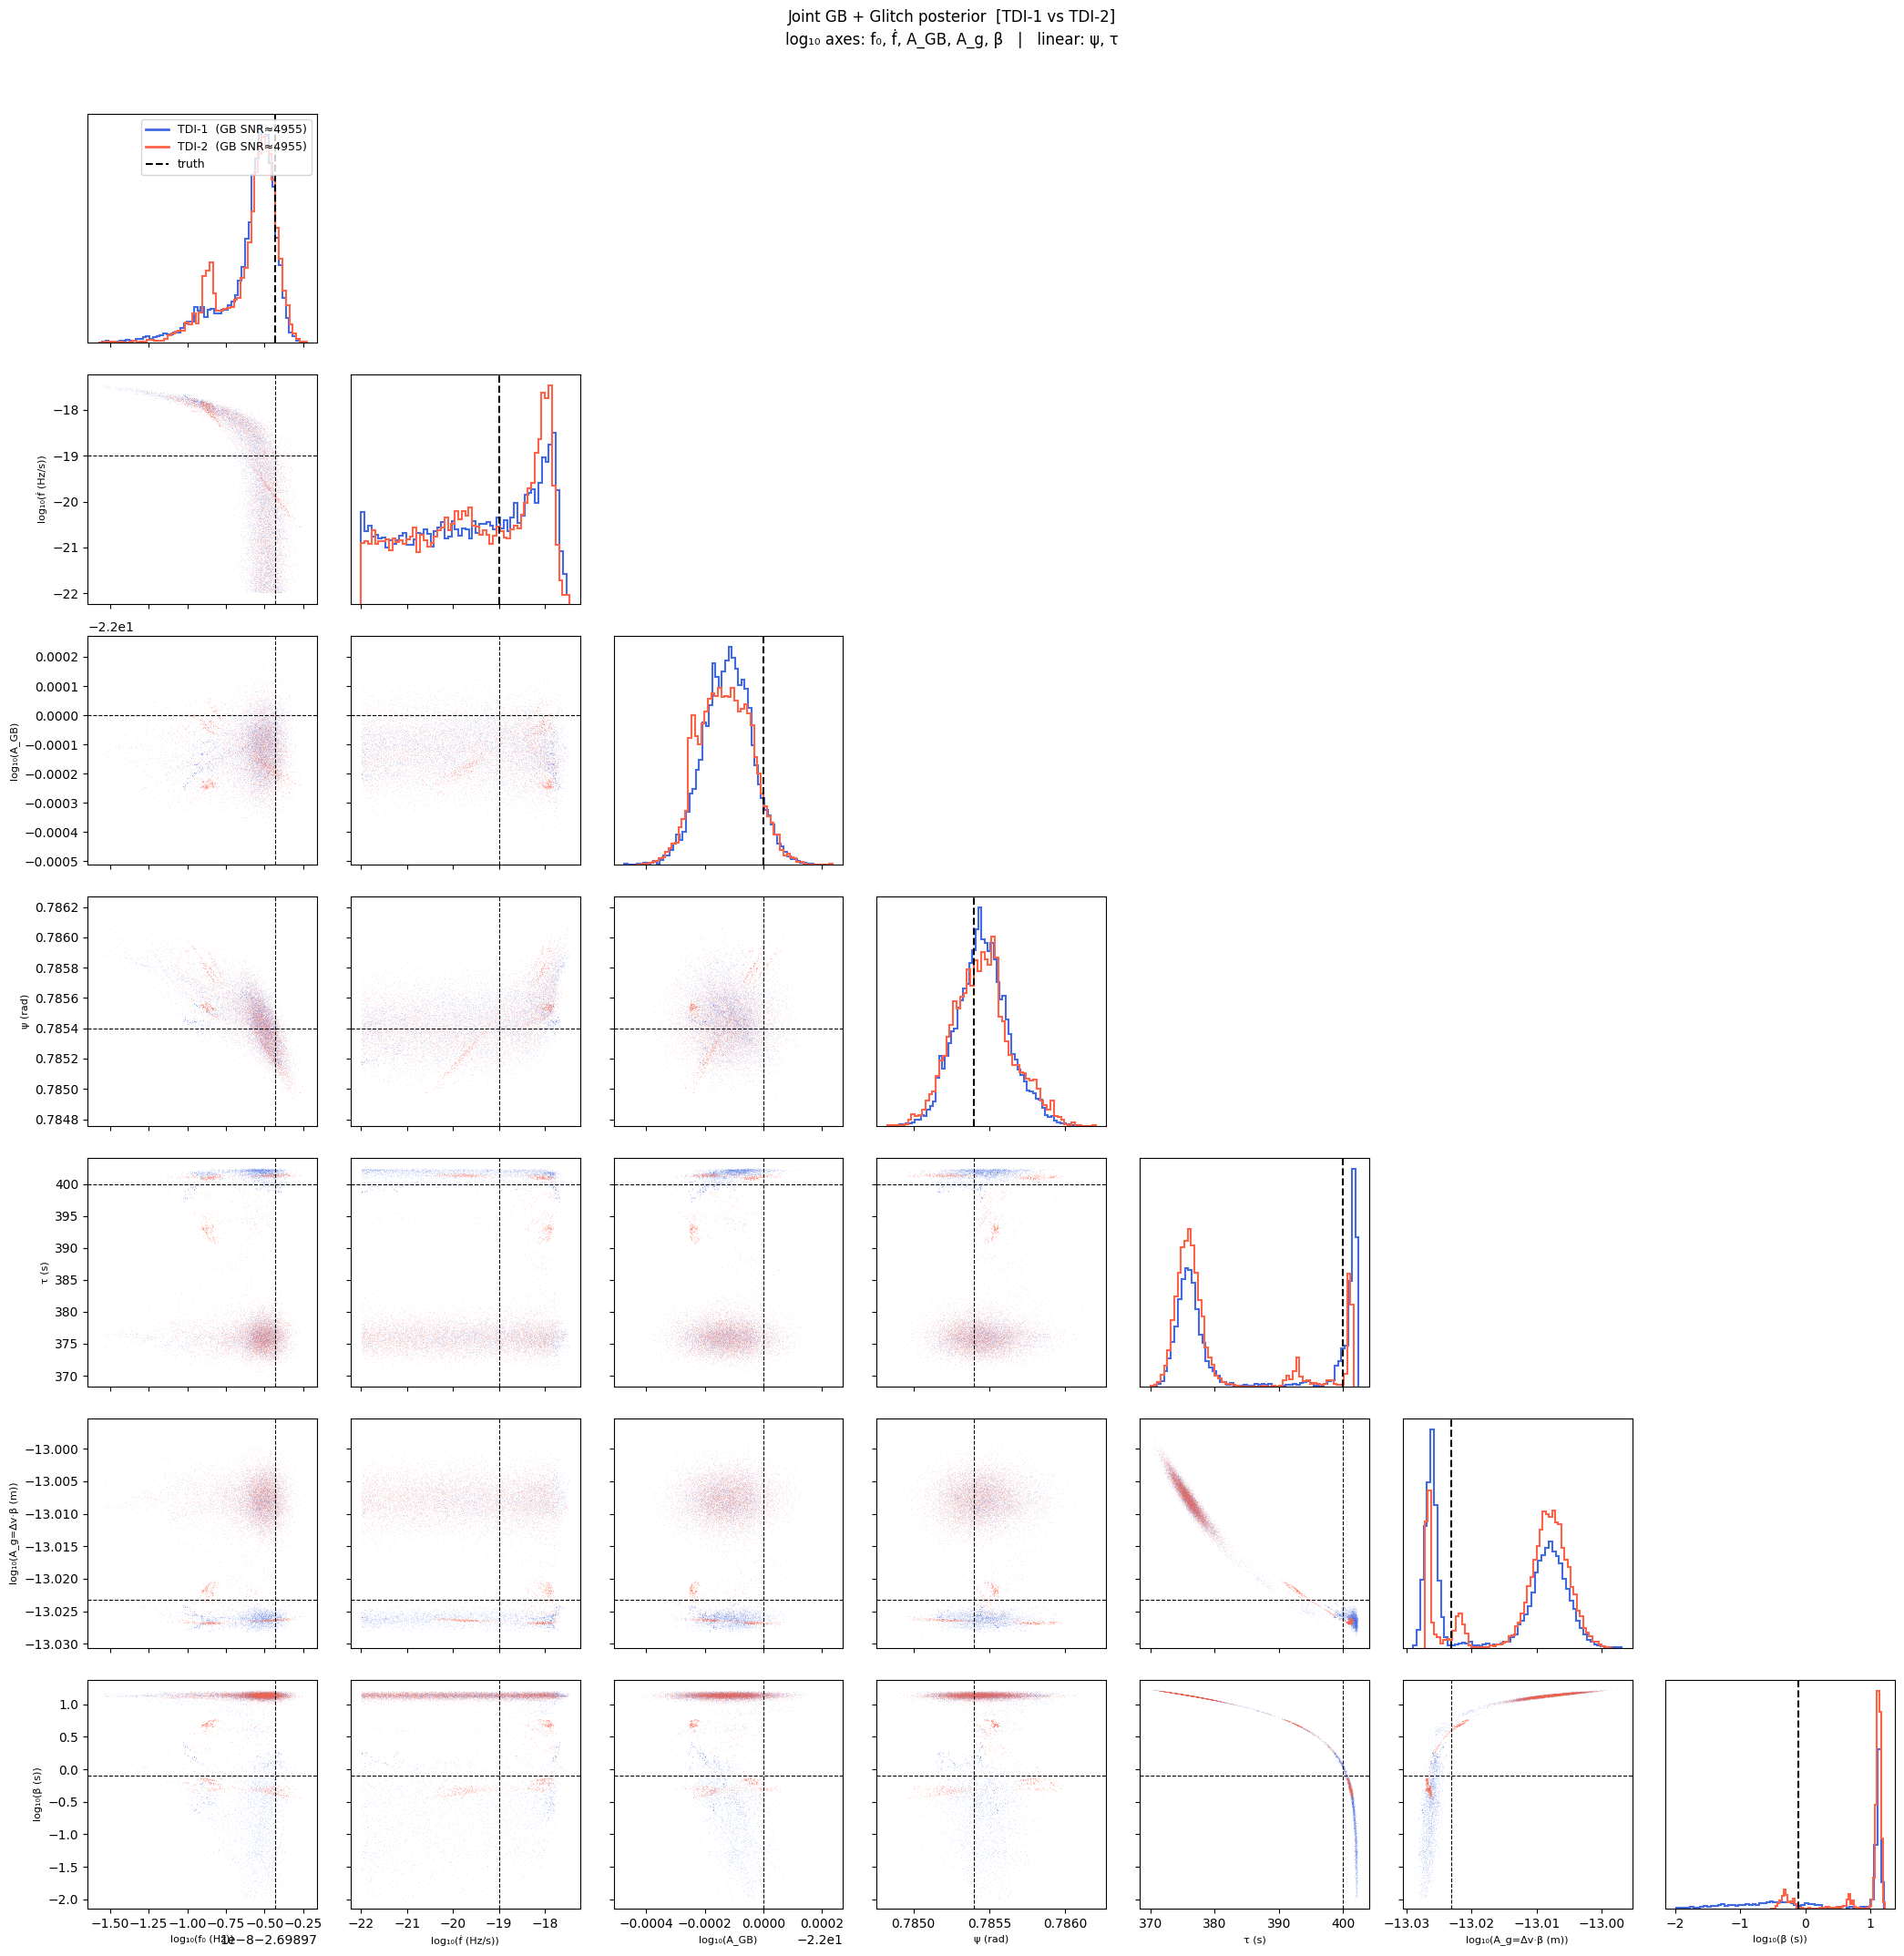

In [15]:
def corner_plot(samples_list, labels_list, colors, param_names, truths, log_axes=None):
    """Simple lower-triangle corner plot."""
    n      = samples_list[0].shape[1]
    log_ax = set(log_axes or [])

    def _v(s, i): return np.log10(np.abs(s[:, i])) if i in log_ax else s[:, i]
    def _t(i):    return np.log10(abs(truths[i]))   if i in log_ax else truths[i]
    def _l(i):    return f'log₁₀({param_names[i]})' if i in log_ax else param_names[i]

    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            if col > row:
                ax.set_visible(False); continue
            if col == row:
                for s, lbl, clr in zip(samples_list, labels_list, colors):
                    ax.hist(_v(s, col), bins=60, density=True,
                            histtype='step', color=clr, lw=1.5, label=lbl)
                ax.axvline(_t(col), color='k', lw=1.5, ls='--')
                ax.set_yticks([])
            else:
                for s, _, clr in zip(samples_list, labels_list, colors):
                    ax.plot(_v(s, col), _v(s, row), ',', color=clr, alpha=0.08, ms=1)
                ax.axvline(_t(col), color='k', lw=0.8, ls='--')
                ax.axhline(_t(row), color='k', lw=0.8, ls='--')
            if row == n-1:
                ax.set_xlabel(_l(col), fontsize=8)
            else:
                ax.set_xticklabels([])
            if col == 0 and row > 0:
                ax.set_ylabel(_l(row), fontsize=8)
            else:
                ax.set_yticklabels([])

    handles  = [plt.Line2D([0],[0], color=c, lw=2, label=l)
                for l, c in zip(labels_list, colors)]
    handles += [plt.Line2D([0],[0], color='k', lw=1.5, ls='--', label='truth')]
    axes[0, 0].legend(handles=handles, fontsize=9, loc='upper right')
    return fig


# Thin chains to ≈10 000 samples
THIN = max(1, chain1.shape[0] // 10_000)
s1   = phys1[::THIN]
s2   = phys2[::THIN]

fig = corner_plot(
    [s1, s2],
    [f'TDI-1  (GB SNR≈{snr_gb1:.0f})', f'TDI-2  (GB SNR≈{snr_gb2:.0f})'],
    ['royalblue', 'tomato'],
    param_names,
    truth_phys,
    log_axes={0, 1, 2, 5, 6}  # log scale for all except psi and tau
)
fig.suptitle(
    'Joint GB + Glitch posterior  [TDI-1 vs TDI-2]\n'
    f'log₁₀ axes: f₀, ḟ, A_GB, A_g, β   |   linear: ψ, τ',
    y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 10. Whitened residual check

Posterior-median model subtracted from data in the GB window.  
Should be white noise (flat at 1) everywhere.

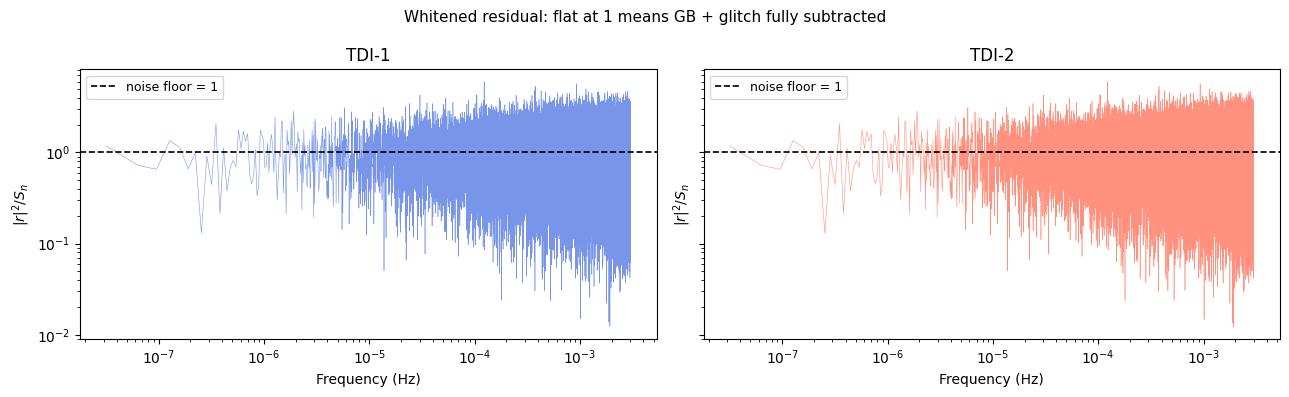

In [16]:
def posterior_model(chain, tdi):
    theta_med = jnp.array(np.median(np.array(chain), axis=0))
    gb8, g3   = to_physical(theta_med)

    # GB signal on full fine grid
    segs = jgb_model.get_tdi(gb8[None], tdi_generation=1.5, tdi_combination='AET')
    h_gb_seg = jnp.stack(segs, axis=0).astype(jnp.complex128)[:, 0, :].T  # (N_GB, 3)
    k_min_med = int(jgb_model.get_kmin(gb8[0:1])[0])
    h_gb_full = jnp.zeros((n_fine, 3), dtype=jnp.complex128)
    h_gb_full = h_gb_full.at[k_min_med + jnp.arange(N_GB)].set(h_gb_seg)

    if tdi == 2:
        h_gb_full = (-TFX1[:, None] * h_gb_full).at[0].set(0+0j)

    # Glitch signal on full fine grid
    h_g_full = glitch_h_tdi1(g3, f_safe) if tdi == 1 else glitch_h_tdi2(g3, f_safe)

    return (h_gb_full + h_g_full).at[0].set(0+0j)

h_med1 = posterior_model(chain1, tdi=1)
h_med2 = posterior_model(chain2, tdi=2)

res1 = data_tdi1 - h_med1
res2 = data_tdi2 - h_med2

f_plot = np.array(freq_fine[1:])
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, res, psd, title, clr in zip(
        axes, [res1, res2], [psd1_fine, psd2_fine],
        ['TDI-1', 'TDI-2'], ['royalblue', 'tomato']):
    wh = np.mean(np.abs(np.array(res[1:]))**2 / np.array(psd[1:]), axis=1)
    ax.loglog(f_plot, wh, color=clr, lw=0.4, alpha=0.7)
    ax.axhline(1.0, color='k', ls='--', lw=1.2, label='noise floor = 1')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(r'$|r|^2 / S_n$')
    ax.set_title(title)
    ax.legend(fontsize=9)
plt.suptitle('Whitened residual: flat at 1 means GB + glitch fully subtracted', fontsize=11)
plt.tight_layout()
plt.show()